# Description

## Description du dataset
- Décomposées en 3 catégories, elles memes décomposées en 3 dataset (train, validation, test)
    - cat 1 : mcqm → multi réponse
    - cat 2 : mcqu → réponse unique
    - cat 3 : oeq → réponse ouverte
- composé d'un context clinic et d'une question
- est catégorisé  dans un "medical_subject"

In [2]:
from google.cloud import storage
from datasets import load_from_disk
import gcsfs
import pandas as pd


c:\Users\Fabien\Desktop\OC\P14\FINE-TUNING_MEDICAL\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
mcqm_datasets = load_from_disk("gs://p14-medical-data/raw_data/mediqal_datasets/mcqm_medical/")
mcqu_datasets = load_from_disk("gs://p14-medical-data/raw_data/mediqal_datasets/mcqu_medical/")
oeq_datasets = load_from_disk("gs://p14-medical-data/raw_data/mediqal_datasets/oeq_medical/")

# Analyse dataset

## Exploration dataset mcqm

In [4]:
df_mcqm = pd.DataFrame(mcqm_datasets["train"])
df_mcqm.head()

,id,clinical_case,question,answer_a,answer_b,answer_c,answer_d,answer_e,correct_answers,task,medical_subject,question_type
0,11399,Plusieurs jours après un contage avec un enfan...,Quelle(s) proposition(s) peut (peuvent) s'appl...,Transmission manuportée,La phase de contagiosité dure 8 jours,Maladie strictement humaine,Confère une immunité,Transmission indirecte possible,"C,D",QCM,Infectious Diseases,Understanding
1,17928,NaN,Quel(s) germe(s) est (sont) responsable(s) de ...,Gardnerella Vaginalis,Trichomonas,Tréponèmes,Candida albicans,Strepto B,"A,B",QCM,Gynecology and Obstetrics,Understanding
2,17520,"Une jeune femme de 26 ans, d'origine française...","En cours d'hospitalisation, laquelle ou lesque...",Réduction de l'apport en protéines animales,Association d'une sulfonylurée à l'insuline,Conservation du même type d'insuline mais augm...,Education à l'autosurveillance glycémique,"Adaptation d'un nouveau schéma thérapeutique, ...","A,D,E",QCM,Endocrinology and Metabolism,Reasoning
3,10875,NaN,Quelles sont parmi les bactéries suivantes res...,Staphylococcus aureus,Salmonella enteritidis,Shigella sonnei,Vibrio cholerae,Campylobacter fetus,"B,C,E",QCM,Pediatrics,Understanding
4,14691,NaN,"Parmi les 5 propositions suivantes, quelle est...",Il est plus souvent d'origine maternelle,La majorité des formes sont inapparentes,Une primo-infection génitale maternelle durant...,L'accouchement par césarienne est indiqué lors...,Aucune chimiothérapie antivirale n'est active,"A,C,D",QCM,Pediatrics,Understanding


In [5]:
df_mcqm.describe(include="all")

,id,clinical_case,question,answer_a,answer_b,answer_c,answer_d,answer_e,correct_answers,task,medical_subject,question_type
count,5767,2185,5767,5767,5767,5767,5767,5767,5767,5767,5767,5767
unique,5767,1227,5545,4946,5009,5060,5053,5115,26,1,27,2
top,11399,"Un sujet de 48 ans, chauffeur routier de trans...",La concentration minimale inhibitrice (CMI) :,Fièvre,Céphalées,Phéochromocytome,Hypertension artérielle,Chloramphénicol,"A,B,C",QCM,Cardiology,Understanding
freq,1,6,4,10,10,7,9,10,351,5767,395,4320


In [6]:
df_mcqm.isna().sum()

id                    0
clinical_case      3582
question              0
answer_a              0
answer_b              0
answer_c              0
answer_d              0
answer_e              0
correct_answers       0
task                  0
medical_subject       0
question_type         0
dtype: int64

<Axes: xlabel='clinical_case', ylabel='Count'>

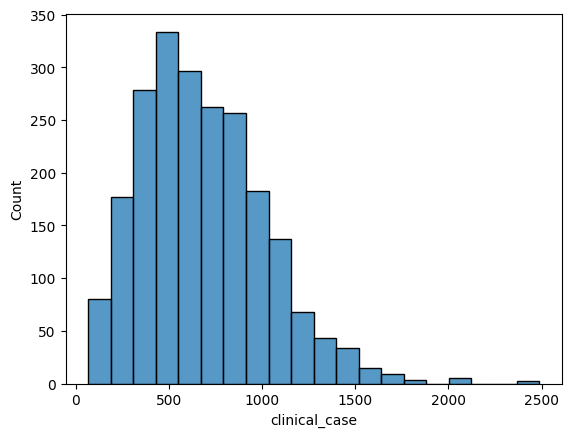

In [28]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
import seaborn as sns
len_clinical_cases = df_mcqm.loc[df_mcqm["clinical_case"].notna(), "clinical_case"].apply(lambda row: len(row))
sns.histplot(len_clinical_cases, bins=20)

**Supprimer les cas cliniques trop longs**

## Exploration dataset mcqu

In [29]:
df_mcqu = pd.DataFrame(mcqu_datasets["train"])
df_mcqu.head()

,id,clinical_case,question,answer_a,answer_b,answer_c,answer_d,answer_e,correct_answers,task,medical_subject,question_type
0,7543,"Monsieur R. âgé de 37 ans, forestier de son mé...",Au sujet des vaccinations :,Le vaccin contre la fièvre jaune est obligatoire,Le vaccin contre la fièvre jaune peut se faire...,Le vaccin contre le choléra est un vaccin qui ...,Le vaccin contre l'hépatite B est conseillé ma...,Les vaccinations contre le tétanos et la polio...,A,QCU,Infectious Diseases,Understanding
1,10495,NaN,"Devant une tuméfaction cervicale médiane, juxt...",Kyste dermoïde,Laryngocèle,Kyste du tractus thyréoglosse,Grenouillette sublinguale,Lithiase salivaire,C,QCU,Otorhinolaryngology (ENT),Understanding
2,17342,Une jeune femme de 24 ans vous consulte pour a...,Le traitement de cette patiente fait appel à :,Chirurgie en urgence,Iode radio-actif en urgence,Iode radio-actif en préparation à la chirurgie,Administration d'antithyroïdiens,Aucun de ces traitements,D,QCU,Endocrinology and Metabolism,Reasoning
3,22883,"Un nouveau-né de sexe masculin, âgé de 3 jours...",Chez ce nouveau-né le bilan biologique à montr...,Ictère par Incompatibilité Rhésus,Ictère par déficit en G6PD,ictère infectieux,Ictère par incompatibilité ABO,Ictère Infectieux,D,QCU,Pediatrics,Understanding
4,17514,Un homme de 63 ans est hospitalisé pour des do...,Pour confirmer le diagnostic de maladie d'Addi...,Test de stimulation par la 1.24 corticotrophin...,Test de freinage par la dexaméthasone,Test de stimulation de l'activité rénine plasm...,Test de restriction hydrique,Scintigraphie surrénale à l'iodocholestérol,A,QCU,Endocrinology and Metabolism,Reasoning


In [31]:
df_mcqu.describe(include="all")

,id,clinical_case,question,answer_a,answer_b,answer_c,answer_d,answer_e,correct_answers,task,medical_subject,question_type
count,10113,3935,10113,10113,10113,10113,10113,10113,10113,10113,10113,10113
unique,10113,1697,9697,7800,7953,8002,8025,7746,5,1,33,2
top,7543,"Une patiente âgée de 34 ans, célibataire, est ...",Quel est le diagnostic le plus probable ?,1+2+3,1+3,2+4,4,1+2+3+4,C,QCU,Cardiology,Understanding
freq,1,13,20,397,304,282,257,258,2720,10113,691,6933


In [32]:
df_mcqu.isna().sum()

id                    0
clinical_case      6178
question              0
answer_a              0
answer_b              0
answer_c              0
answer_d              0
answer_e              0
correct_answers       0
task                  0
medical_subject       0
question_type         0
dtype: int64

In [30]:
df_mcqu[df_mcqu.duplicated()]

,id,clinical_case,question,answer_a,answer_b,answer_c,answer_d,answer_e,correct_answers,task,medical_subject,question_type


<Axes: xlabel='clinical_case', ylabel='Count'>

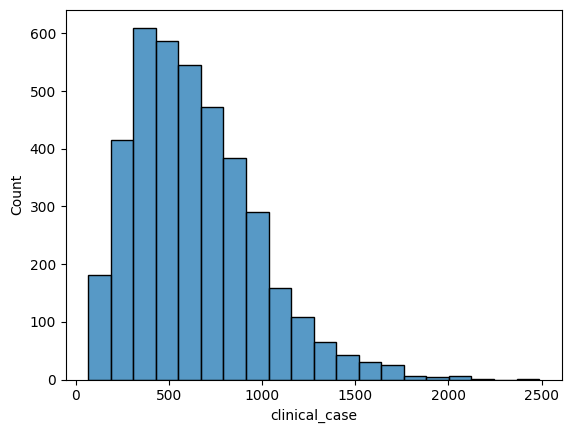

In [33]:
len_clinical_cases = df_mcqu.loc[df_mcqu["clinical_case"].notna(), "clinical_case"].apply(lambda row: len(row))
sns.histplot(len_clinical_cases, bins=20)

In [34]:
df_mcqu["correct_answers"].value_counts()

correct_answers
C    2720
D    2409
B    2032
E    1701
A    1251
Name: count, dtype: int64

In [2]:
import pandas as pd
pd.set_option('display.max_colwidth', False)
pd.set_option('display.max_rows', None)
df = pd.read_parquet("gs://p14-medical-data/processed_data/mediqal_dataset/mediqal_train.parquet")
df.head(100)


,question,answer
0,"Devant une tuméfaction cervicale médiane, juxta-hyoïdienne, qui ascensionne à la déglutition, quel diagnostic évoquez-vous ?",Kyste du tractus thyréoglosse
1,Le vaccin antidiphtérique est constitué par :,L'anatoxine diphtérique
2,"(cochez la réponse juste) La réaction neuro-hormonale comprend les agents vasoconstricteurs et antinatriurétique suivants, sauf un. Lequel ?",Bradykinine
3,A propos de l'infarctus du myocarde :,Aucune des propositions précédentes n'est exacte
4,Une des affirmations concernant la castration radiothérapique dans le cancer du sein est vraie. Laquelle ?,Elle allonge l'intervalle libre sans récidive
5,Le signe du liseré pleural est à rechercher devant :,Pneumothorax
6,"Un nourrisson de 18 mois a depuis l'âge de 10 mois des otites aiguës récidivantes survenant en moyenne tous les 2 mois et traitées à chaque fois soit par antibiotique, soit par paracentèse suivie d'une antibiothérapie. Dans l'intervalle des otites, les tympans sont rétractés : l'audiométrie est normale . Quel traitement est-on en droit de proposer en premier :",Adénoïdectomie
7,La plaque de psoriasis est caractérisée par un des signes suivants :,Sa desquamation importante
8,(cochez la réponse fausse) Le syndrome de Widal se caractérise par :,Une non réponse au traitement bêta mimétique
9,"Parmi les acides gras suivants, un d'entre eux élève la cholestérolémie. Lequel ?",Acide palmitique


## Exploration dataset oeq